矩阵 A（秩为1）
A = 
 [[1 2 3]
 [2 4 6]
 [3 6 9]]

秩: 1

列空间 C(A) 的基（维度 1）:
[[-0.26726124]
 [-0.53452248]
 [-0.80178373]]

行空间 C(A^T) 的基（维度 1）:
[[-0.26726124]
 [-0.53452248]
 [-0.80178373]]

任意 x=[1 2 3] 产生的 Ax=[14 28 42]
Ax 是否在列空间内？答案是肯定的（因为 Ax 就是列的组合）

2D 可视化：秩为1的矩阵
A2 = 
 [[1 2]
 [2 4]]


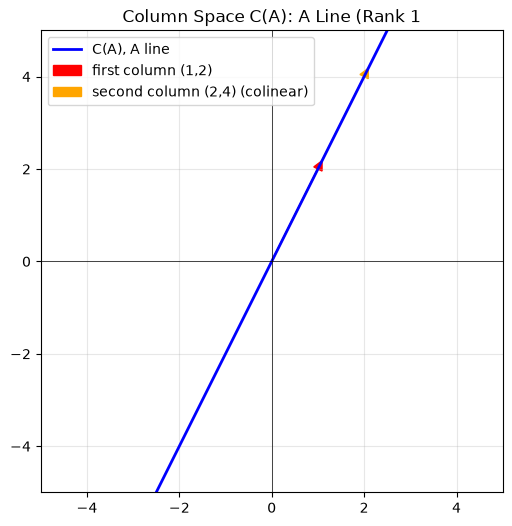

In [6]:
import numpy as np
from scipy.linalg import svd, null_space
import matplotlib.pyplot as plt

# ---- 创建一个低秩矩阵（有冗余） ----
A = np.array([
    [1, 2, 3],
    [2, 4, 6],
    [3, 6, 9]
])  # 第二列 = 2*第一列，第三列 = 3*第一列，秩 = 1

print("=" * 60)
print("矩阵 A（秩为1）")
print("=" * 60)
print("A = \n", A)

# ---- 计算秩 ----
rank = np.linalg.matrix_rank(A)
print(f"\n秩: {rank}")

# ---- 列空间：用 SVD 提取列空间的基 ----
# SVD 分解：A = U @ S @ Vt
# U 的前 r 列是列空间的基
U, S, Vt = svd(A, full_matrices=False)
col_space_basis = U[:, :rank]  # 列空间的基（在输出空间中）

print(f"\n列空间 C(A) 的基（维度 {rank}）:")
print(col_space_basis)

# ---- 行空间：Vt 的前 r 行是行空间的基 ----
row_space_basis = Vt[:rank, :].T  # 行空间的基（在输入空间中）
print(f"\n行空间 C(A^T) 的基（维度 {rank}）:")
print(row_space_basis)

# ---- 验证：列空间中的任何向量都是列的组合 ----
# 取任意 x，Ax 应该落在列空间内
x = np.array([1, 2, 3])
b = A @ x
print(f"\n任意 x={x} 产生的 Ax={b}")
print(f"Ax 是否在列空间内？答案是肯定的（因为 Ax 就是列的组合）")

# ---- 可视化：秩为1的矩阵的列空间是一条直线 ----
# 为了可视化，我们取一个 2x2 的秩1矩阵
A2 = np.array([[1, 2], [2, 4]])
print("\n" + "=" * 60)
print("2D 可视化：秩为1的矩阵")
print("=" * 60)
print("A2 = \n", A2)

# 列空间是一条穿过 (1,2) 的直线
# 生成这条直线上的点
t = np.linspace(-3, 3, 100)
line_points = np.array([t * 1, t * 2]).T  # 沿着 (1,2) 方向

# 图表使用英文
plt.figure(figsize=(8, 6))
plt.plot(line_points[:, 0], line_points[:, 1], 'b-', linewidth=2, label='C(A), A line')
plt.arrow(0, 0, 1, 2, head_width=0.2, head_length=0.2, fc='red', ec='red', label='first column (1,2)')
plt.arrow(0, 0, 2, 4, head_width=0.2, head_length=0.2, fc='orange', ec='orange', label='second column (2,4) (colinear)')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.title('Column Space C(A): A Line (Rank 1')
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

In [11]:
import numpy as np
from scipy.linalg import null_space

# ---- 秩为2，列数为3的矩阵（有一个冗余特征） ----
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])  # 第三列 = 2*第二列 - 第一列，秩 = 2

print("=" * 60)
print("矩阵 A（秩为2，列数为3）")
print("=" * 60)
print("A = \n", A)

rank = np.linalg.matrix_rank(A)
n = A.shape[1]
print(f"秩: {rank}, 列数: {n}, 零空间维度: {n - rank}")

# ---- 计算零空间的基 ----
ns = null_space(A)
print(f"\n零空间 N(A) 的基（维度 {n - rank}）:")
print(ns)

# ---- 验证：A @ (零空间基) = 0 ----
print(f"\n验证 A @ ns = {A @ ns}")
# 应该接近 [0, 0, 0]^T

# ---- 解读零空间的含义 ----
# 零空间的基表示列之间的线性关系
# 这里 ns 是一个向量，表示第三列和第一、二列的关系
print("\n解读：零空间的基表示列之间的线性关系")
print(f"ns = {ns.flatten()} 意味着:")
print(f"  {ns[0].item():.2f} * (第1列) + {ns[1].item():.2f} * (第2列) + {ns[2].item():.2f} * (第3列) = 0")

# ---- 演示：不同的 x 产生相同的 Ax ----
x1 = np.array([1, 0, 0])
x2 = x1 + ns.flatten()  # 加上零空间中的向量

print(f"\nx1 = {x1}, Ax1 = {A @ x1}")
print(f"x2 = {x2.round(3)}, Ax2 = {A @ x2.round(3)}")
print("Ax1 和 Ax2 相同！说明 x1 和 x2 产生相同的输出。")
print("这就是“不确定性”——不同的特征组合给出相同的预测。")

矩阵 A（秩为2，列数为3）
A = 
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
秩: 2, 列数: 3, 零空间维度: 1

零空间 N(A) 的基（维度 1）:
[[-0.40824829]
 [ 0.81649658]
 [-0.40824829]]

验证 A @ ns = [[1.66533454e-16]
 [3.33066907e-16]
 [9.43689571e-16]]

解读：零空间的基表示列之间的线性关系
ns = [-0.40824829  0.81649658 -0.40824829] 意味着:
  -0.41 * (第1列) + 0.82 * (第2列) + -0.41 * (第3列) = 0

x1 = [1 0 0], Ax1 = [1 4 7]
x2 = [ 0.592  0.816 -0.408], Ax2 = [1. 4. 7.]
Ax1 和 Ax2 相同！说明 x1 和 x2 产生相同的输出。
这就是“不确定性”——不同的特征组合给出相同的预测。


秩-零度定理验证
案例1: 满秩方阵 (2×2, r=2):
  形状: 2×2
  秩: 2
  零度 (零空间维度): 0
  秩 + 零度 = 2 + 0 = 2 = 列数 ✅
案例2: 奇异方阵 (2×2, r=1):
  形状: 2×2
  秩: 1
  零度 (零空间维度): 1
  秩 + 零度 = 1 + 1 = 2 = 列数 ✅
案例3: 长方形矩阵 (3×2, 列满秩):
  形状: 3×2
  秩: 2
  零度 (零空间维度): 0
  秩 + 零度 = 2 + 0 = 2 = 列数 ✅
案例4: 长方形矩阵 (2×3, 行满秩):
  形状: 2×3
  秩: 2
  零度 (零空间维度): 1
  秩 + 零度 = 2 + 1 = 3 = 列数 ✅


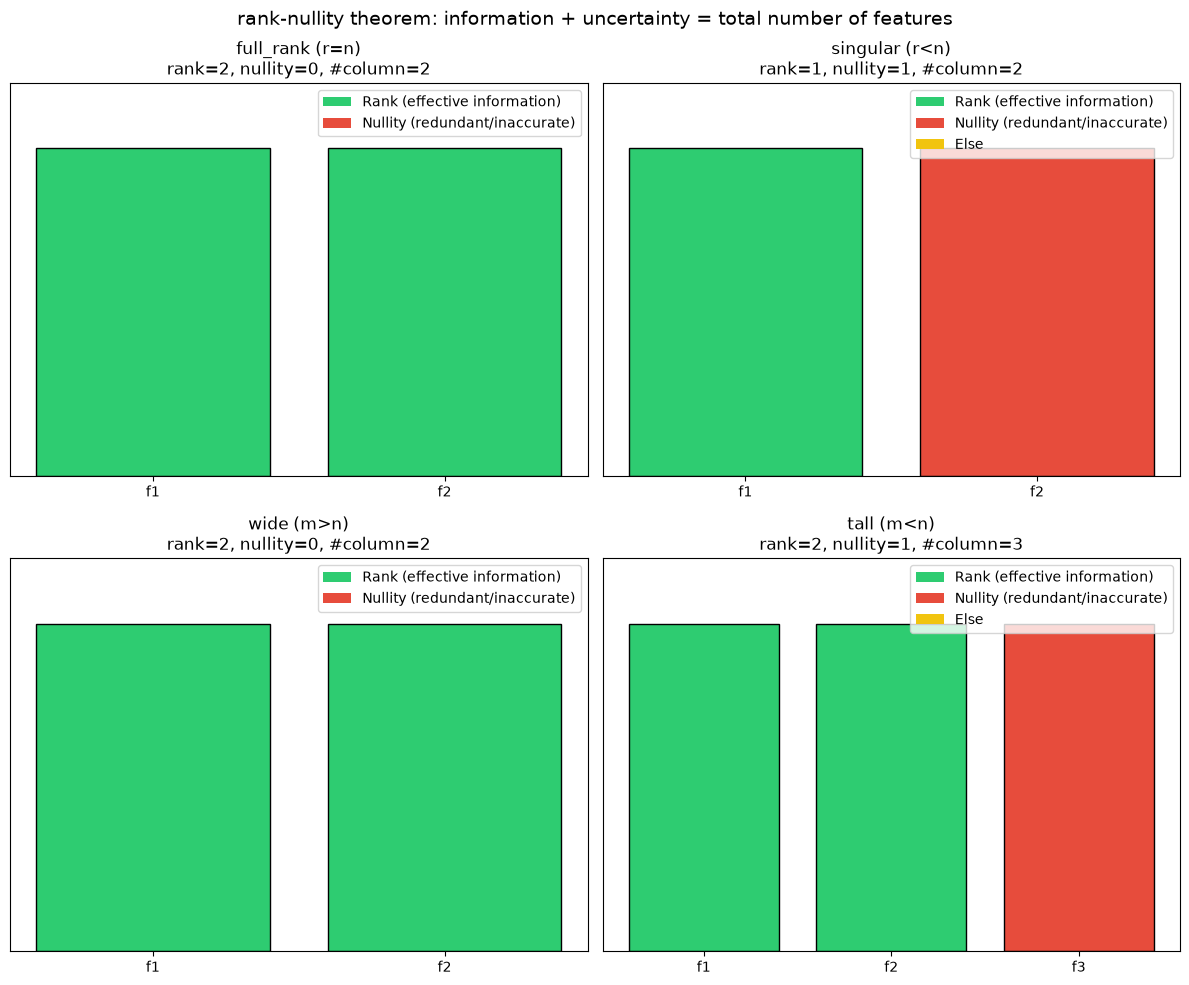

In [13]:
import numpy as np
from scipy.linalg import null_space
import matplotlib.pyplot as plt

# ---- 生成不同秩的矩阵，观察秩-零度关系 ----
def analyze_matrix(A, name):
    m, n = A.shape
    rank = np.linalg.matrix_rank(A)
    nullity = n - rank
    print(f"{name}:")
    print(f"  形状: {m}×{n}")
    print(f"  秩: {rank}")
    print(f"  零度 (零空间维度): {nullity}")
    print(f"  秩 + 零度 = {rank} + {nullity} = {n} = 列数 ✅")
    return rank, nullity

print("=" * 60)
print("秩-零度定理验证")
print("=" * 60)

# 案例1：满秩方阵
A1 = np.array([[1, 2], [3, 4]])
analyze_matrix(A1, "案例1: 满秩方阵 (2×2, r=2)")

# 案例2：奇异方阵
A2 = np.array([[1, 2], [2, 4]])
analyze_matrix(A2, "案例2: 奇异方阵 (2×2, r=1)")

# 案例3：长方形矩阵 (m > n)
A3 = np.array([[1, 2], [3, 4], [5, 6]])
analyze_matrix(A3, "案例3: 长方形矩阵 (3×2, 列满秩)")

# 案例4：长方形矩阵 (m < n)
A4 = np.array([[1, 2, 3], [4, 5, 6]])
analyze_matrix(A4, "案例4: 长方形矩阵 (2×3, 行满秩)")

# ---- 可视化：不同形状矩阵的“信息结构” ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

matrices = [A1, A2, A3, A4]
# titles = ["满秩方阵 (r=n)", "奇异方阵 (r<n)", "长方形 (m>n)", "长方形 (m<n)"]
titles = ["full_rank (r=n)", "singular (r<n)", "wide (m>n)", "tall (m<n)"]

for idx, (A, title) in enumerate(zip(matrices, titles)):
    m, n = A.shape
    rank = np.linalg.matrix_rank(A)
    nullity = n - rank
    
    ax = axes[idx // 2, idx % 2]
    
    # 画一个示意图
    # 用颜色块表示“有效信息”和“冗余/不确定性”
    colors = ['#2ecc71'] * rank + ['#e74c3c'] * nullity
    # 补齐到 n 个
    if len(colors) < n:
        colors = colors + ['#f1c40f'] * (n - len(colors))
    
    ax.bar(range(n), [1]*n, color=colors, edgecolor='black', linewidth=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels([f'f{i+1}' for i in range(n)])
    ax.set_title(f"{title}\nrank={rank}, nullity={nullity}, #column={n}")
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rank (effective information)'),
        Patch(facecolor='#e74c3c', label='Nullity (redundant/inaccurate)')
    ]
    if n - rank - len([c for c in colors if c == '#f1c40f']) > 0:
        legend_elements.append(Patch(facecolor='#f1c40f', label='Else'))
    ax.legend(handles=legend_elements, loc='upper right')

plt.suptitle('rank-nullity theorem: information + uncertainty = total number of features', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from scipy.linalg import null_space, svd

# ---- 矩阵 A：3行2列（3个方程，2个未知数） ----
A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

print("=" * 60)
print("矩阵 A（3行2列，过定系统）")
print("=" * 60)
print("A = \n", A)

m, n = A.shape
rank = np.linalg.matrix_rank(A)
print(f"形状: {m}×{n}, 秩: {rank}")

# ---- 左零空间 N(A^T)：维度 = m - r ----
left_nullity = m - rank
print(f"左零空间维度: {left_nullity}")

# ---- 用 null_space 计算 A^T 的零空间 ----
# N(A^T) 就是 A^T 的零空间
left_null_basis = null_space(A.T)
print(f"\n左零空间 N(A^T) 的基:\n{left_null_basis}")

# ---- 验证：A^T @ y = 0 ----
y = left_null_basis.flatten() if left_null_basis.size > 0 else None
if y is not None:
    print(f"\n验证: A^T @ y = {A.T @ y}")
    print(f"应该接近 [0, 0]^T ✅")

# ---- 关键洞察：左零空间中的 b 是不可达的 ----
print("\n" + "=" * 60)
print("关键洞察：左零空间中的 b 是无法到达的")
print("=" * 60)

# 取一个在列空间内的 b（可达）
b_col = A @ np.array([1, 2])  # 列组合，一定在列空间内
# 取一个在左零空间内的 b（不可达）
if y is not None:
    b_null = y * 10  # 放大一点，看得更清楚

    # 尝试解 Ax = b_col
    x_col, resid_col, rank_col, s_col = np.linalg.lstsq(A, b_col, rcond=None)
    print(f"b_col = {b_col} (在列空间内)")
    print(f"最小二乘解: x = {x_col}")
    print(f"残差: {resid_col[0]:.6f} (接近0，完美匹配)")

    # 尝试解 Ax = b_null
    x_null, resid_null, rank_null, s_null = np.linalg.lstsq(A, b_null, rcond=None)
    print(f"\nb_null = {b_null} (在左零空间内)")
    print(f"最小二乘解: x = {x_null}")
    print(f"残差: {resid_null[0]:.6f} (远大于0，无法完美匹配)")

    # 残差就是 b_null 在左零空间中的分量
    # 验证：残差的方向就是左零空间的基
    residual = b_null - A @ x_null
    print(f"\n残差方向: {residual}")
    print(f"左零空间基方向: {y}")
    print(f"残差和左零空间基是否平行？{np.allclose(residual / np.linalg.norm(residual), y / np.linalg.norm(y))}")

矩阵 A（3行2列，过定系统）
A = 
 [[1 2]
 [3 4]
 [5 6]]
形状: 3×2, 秩: 2
左零空间维度: 1

左零空间 N(A^T) 的基:
[[ 0.40824829]
 [-0.81649658]
 [ 0.40824829]]

验证: A^T @ y = [7.21644966e-16 3.33066907e-16]
应该接近 [0, 0]^T ✅

关键洞察：左零空间中的 b 是无法到达的
b_col = [ 5 11 17] (在列空间内)
最小二乘解: x = [1. 2.]
残差: 0.000000 (接近0，完美匹配)

b_null = [ 4.0824829  -8.16496581  4.0824829 ] (在左零空间内)
最小二乘解: x = [0. 0.]
残差: 100.000000 (远大于0，无法完美匹配)

残差方向: [ 4.0824829  -8.16496581  4.0824829 ]
左零空间基方向: [ 0.40824829 -0.81649658  0.40824829]
残差和左零空间基是否平行？True
